In [1]:
import sys
from pathlib import Path

from matplotlib import pyplot as plt

import lsstypes as types
sys.path.insert(0, '../../')
from clustering_statistics import tools

stats_dir = Path(f'/global/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe')

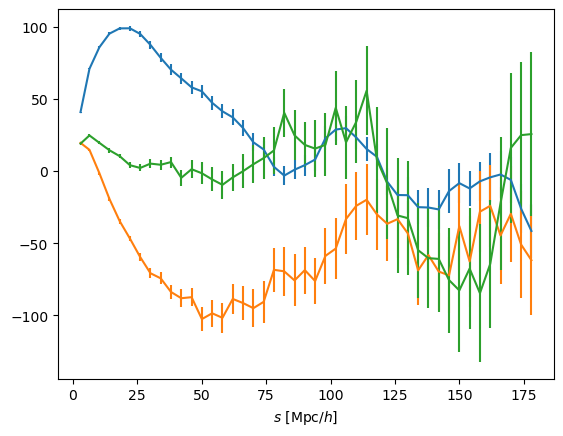

In [2]:
fn = tools.get_stats_fn(stats_dir=stats_dir, kind='recon_particle2_correlation', version='data-dr1-v1.5',
                        region='GCcomb', weight='default-FKP', tracer='LRG', zrange=(0.4, 0.6), jackknife={'nsplits': 60})
correlation = types.read(fn)
# rebin by a factor 4 and project to multipoles
poles, cov = correlation.select(s=slice(0, None, 4)).project(ells=[0, 2, 4], kw_covariance={})

fig, ax = plt.subplots()
for ell in poles.ells:
    pole = poles.get(ells=ell)
    std = cov.at.observable.get(ells=ell).std()
    ax.errorbar(s:=pole.coords('s'), s**2 * pole, s**2 * std)
ax.set_xlabel(r'$s^2 \xi_\ell(s)$ [$(\mathrm{Mpc}/h)^2$]')
ax.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
plt.show()

In [3]:
print(correlation.get('RR').get(realization=0, cross='ii').attrs, correlation.get('RR').get(realization=0, cross='ij').attrs, correlation.get('RR').get(realization=0, cross='ji').attrs)

{'wsum': array([9396.43452153, 9396.43452153])} {'wsum': array([  9396.43452153, 447559.0966775 ])} {'wsum': array([447559.0966775 ,   9396.43452153])}


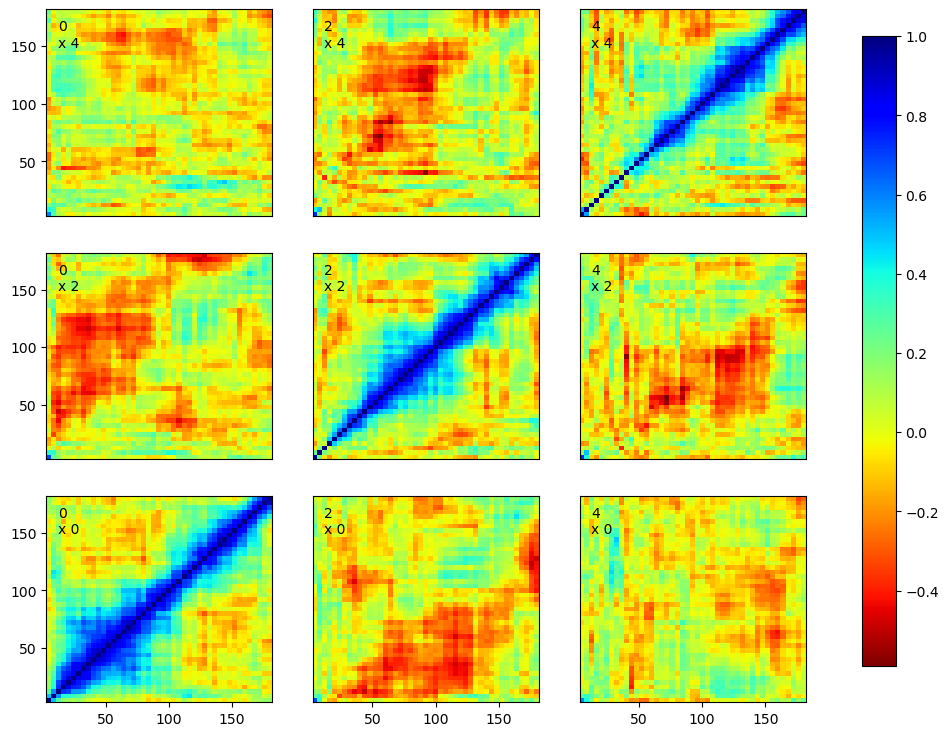

In [4]:
cov.plot(corrcoef=True);

## As a comparison, the 2024 measurements

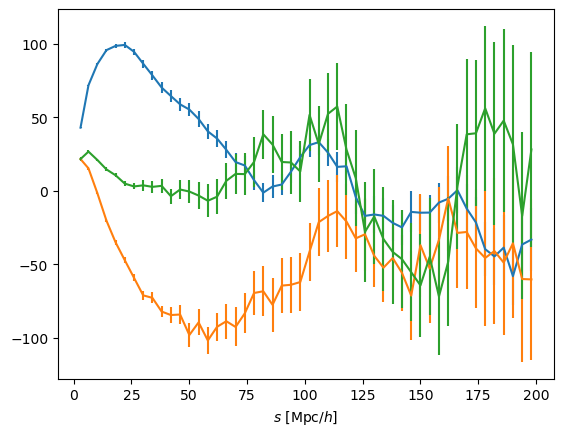

In [5]:
fn = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.2/unblinded/desipipe/2pt/recon_sm15_IFFT_recsym/xi/smu/allcounts_LRG_GCcomb_z0.4-0.6_default_FKP_lin_nran8_njack60_split20.npy'
from pycorr import TwoPointCorrelationFunction
from lsstypes.external import from_pycorr
correlation = from_pycorr(TwoPointCorrelationFunction.load(fn))

poles, cov = correlation.select(s=slice(0, None, 4)).project(ells=[0, 2, 4], kw_covariance={})
fig, ax = plt.subplots()
for ell in poles.ells:
    pole = poles.get(ells=ell)
    std = cov.at.observable.get(ells=ell).std()
    ax.errorbar(s:=pole.coords('s'), s**2 * pole, s**2 * std)
ax.set_xlabel(r'$s^2 \xi_\ell(s)$ [$(\mathrm{Mpc}/h)^2$]')
ax.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
plt.show()

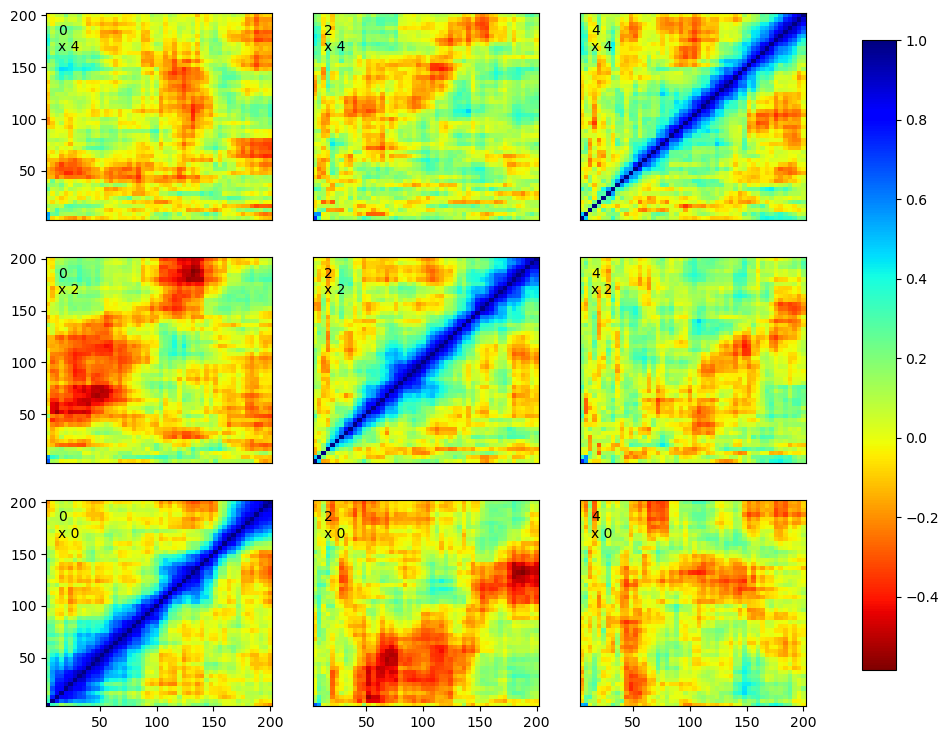

In [6]:
cov.plot(corrcoef=True);